In [ ]:
import os
import os.path
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive')
import binvox_rw

In [ ]:
import os
file_paths=[]
directory = '/content/drive/MyDrive/Featurenet_exp/names'

with open(os.path.join(directory, 'file_paths.txt'), 'r') as f:
    file_paths = [line.strip() for line in f]

In [ ]:
file_path=file_paths[1777]

In [ ]:
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_3d_array(fp)
       voxels=model.data


In [ ]:
def all_zeros_coordinates (voxels,x,y,z):

    for i in range(64):
        for j in range(64):
            for k in range(64):
                if voxels[i, j, k] == 0:
                  x.append(i)
                  y.append(j)
                  z.append(k)


    return x,y,z

In [ ]:
def get_com (x,y,z):
    return np.sum(x)/len(x),np.sum(y)/len(y),np.sum(z)/len(z)

In [ ]:
'''
Assuming the 0 th direction is x , 1st is y and 3 rd is z

'''
def get_axis(voxels_data):
  x=0
  y=0
  z=0
  axis=[]
  if np.any(voxels_data[0,:,:]==0):
    x=1
  if np.any(voxels_data[:,0,:]==0):
    y=1
  if np.any(voxels_data[:,:,0]==0):
    z=1
  if x==1:
    axis.append('x-axis')
  if y==1:
    axis.append('y-axis')
  if z==1:
    axis.append('z-axis')
  return axis

get_axis(voxels)

['y-axis']

In [ ]:
def get_depth(voxels_data,axis,x_cords,y_cords,z_cords):
  depth=[]
  for i in range(len(axis)):
    if axis[i]=='x-axis':
      depth.append(np.max(x_cords))
    if axis[i]=='y-axis':
      depth.append(np.max(y_cords))
    if axis[i]=='z-axis':
      depth.append(np.max(z_cords))
  return depth


In [ ]:
def get_voxel_information(voxels_data):
  axis=[]
  x_cords=[]
  y_cords=[]
  z_cords=[]
  depth=[]

  x_cords,y_cords,z_cords=all_zeros_coordinates(voxels_data,x_cords,y_cords,z_cords)
  x_com,y_com,z_com=get_com(x_cords,y_cords,z_cords)
  axis=get_axis(voxels_data)
  depth=get_depth(voxels_data,axis,x_cords,y_cords,z_cords)
  print(f"x_com : {x_com}  y_com : {y_com} z_com : {z_com}")
  print(f"axis : {axis}")
  print(f"depth : {depth}")
  return x_cords,y_cords,z_cords,axis,depth




In [ ]:
x,y,z,axis,depth=get_voxel_information(voxels)

x_com : 32.207299270072994  y_com : 31.5 z_com : 26.778102189781023
axis : ['y-axis']
depth : [63]


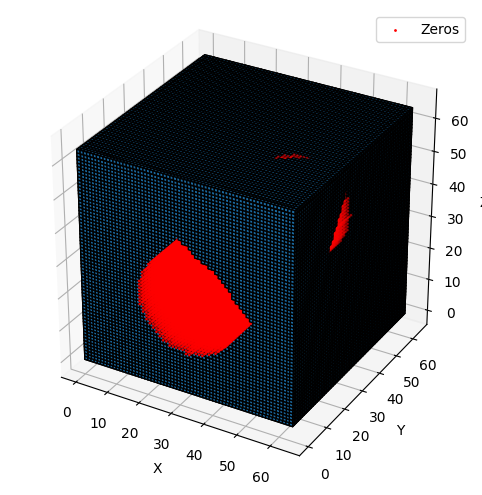

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Extract coordinates of zeros
# zero_coords = np.argwhere(voxels == 0)
# x, y, z = zero_coords[:, 0], zero_coords[:, 1], zero_coords[:, 2]

# Create a figure and axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the voxel data
ax.voxels(voxels, edgecolor='k')

# Overlay the zero coordinates
ax.scatter(x, y, z, color='red', s=1, label='Zeros')

# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal
ax.legend()

# Show plot
plt.show()

In [ ]:
'''
Used to create 3d representation of the voxel data
'''

# Create a figure and axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot voxels
ax.voxels(voxels, edgecolor='k')
ax.plot3D(x, y, z)

# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal

# Show plot
plt.show()
